In [4]:
"""
From Mask-RCNN RGBD
script to convert matlab file containing dataset to python readable format 
NYU-V2 Dataset
"""
import os, sys
import h5py
import numpy as np

dataset_dir = 'nyuv2'
file = 'nyu_depth_v2_labeled.mat'
file_path = os.path.join(dataset_dir, file)

includes = ["images", "depths", "instances", "labels"]
subsets = ["training", "validation"]
n_img = 1449.0
thresh = 0.8

for subset in subsets:
    for key, value in h5py.File(file_path).items():
        if key in includes:
            directory = os.path.join('data', subset, key)
            if not os.path.exists(directory):
                os.makedirs(directory)
            print("Converting {} to .npy".format(key))
            for idx, img in enumerate(value):
                if (subset == "training" and (idx + 1) / n_img <= thresh) or (subset == "validation" and (idx + 1) / n_img > thresh):
                    np.save(os.path.join(directory, "{}.npy".format(idx)), np.array(img))

for key, value in h5py.File(file_path).items():
    if key == "names":
        names = value
    elif key == "namesToIds":        
        namesToIds = value

print("Done")

Converting depths to .npy
Converting images to .npy
Converting instances to .npy
Converting labels to .npy
Converting depths to .npy
Converting images to .npy
Converting instances to .npy
Converting labels to .npy
Done


ERROR! Session/line number was not unique in database. History logging moved to new session 255


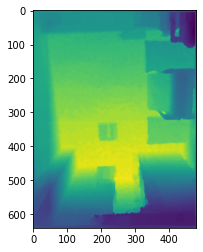

In [1]:
import numpy as np
import matplotlib.pyplot as plt 
%matplotlib inline 
img = np.load('../data/external/NYU-V2/training/depths/0.npy')
plt.imshow(img)
plt.show()